In [5]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
from data_loader import load_processed_data

tickers = ["TSLA", "BND", "SPY"]
data = load_processed_data(tickers, input_dir="../data/processed")

future_predictions = np.load("../data/processed/tsla_future_predictions.npy")

print(data["TSLA"].tail())
print(future_predictions[-5:])

             Adj Close       Close        High         Low        Open  \
Date                                                                     
2026-06-23  381.609985  381.609985  392.869995  379.059998  392.609985   
2026-06-24  375.529999  375.529999  384.579987  373.049988  380.079987   
2026-06-25  375.119995  375.119995  379.119995  371.220001  375.269989   
2026-06-26  379.709991  379.709991  387.799988  368.600006  370.149994   
2026-06-29  411.839996  411.839996  413.269989  379.299988  381.790009   

              Volume  Daily Return  
Date                                
2026-06-23  50420200     -0.057869  
2026-06-24  37081400     -0.015932  
2026-06-25  30138800     -0.001092  
2026-06-26  53434100      0.012236  
2026-06-29  57645800      0.084617  
[[164.71921806]
 [163.65901592]
 [162.59609477]
 [161.53031445]
 [160.46156286]]


In [7]:
last_known_price = data["TSLA"]["Adj Close"].iloc[-1]
forecasted_final_price = future_predictions[-1][0]

# Total return over the 6-month forecast horizon
total_forecast_return = (forecasted_final_price / last_known_price) - 1

# Annualize: compound the 6-month return to a 12-month equivalent
tsla_expected_annual_return = (1 + total_forecast_return) ** 2 - 1

print(f"Last known price: {last_known_price:.2f}")
print(f"Forecasted price (6mo): {forecasted_final_price:.2f}")
print(f"Total 6-month forecast return: {total_forecast_return:.4f} ({total_forecast_return*100:.2f}%)")
print(f"Annualized expected return (TSLA): {tsla_expected_annual_return:.4f} ({tsla_expected_annual_return*100:.2f}%)")

Last known price: 411.84
Forecasted price (6mo): 160.46
Total 6-month forecast return: -0.6104 (-61.04%)
Annualized expected return (TSLA): -0.8482 (-84.82%)


In [8]:
bnd_daily_return_mean = data["BND"]["Adj Close"].pct_change().mean()
spy_daily_return_mean = data["SPY"]["Adj Close"].pct_change().mean()

trading_days = 252
bnd_expected_annual_return = (1 + bnd_daily_return_mean) ** trading_days - 1
spy_expected_annual_return = (1 + spy_daily_return_mean) ** trading_days - 1

print(f"BND annualized expected return: {bnd_expected_annual_return:.4f} ({bnd_expected_annual_return*100:.2f}%)")
print(f"SPY annualized expected return: {spy_expected_annual_return:.4f} ({spy_expected_annual_return*100:.2f}%)")

BND annualized expected return: 0.0202 (2.02%)
SPY annualized expected return: 0.1552 (15.52%)


In [9]:
data = load_processed_data(tickers, input_dir="../data/processed")
future_predictions = np.load("../data/processed/tsla_future_predictions.npy")
print(future_predictions[-5:])

[[155.4543029 ]
 [154.9173973 ]
 [154.38349102]
 [153.85245792]
 [153.32418587]]


In [10]:
last_known_price = data["TSLA"]["Adj Close"].iloc[-1]
forecasted_final_price = future_predictions[-1][0]

total_forecast_return = (forecasted_final_price / last_known_price) - 1
tsla_expected_annual_return = (1 + total_forecast_return) ** 2 - 1

print(f"Last known price: {last_known_price:.2f}")
print(f"Forecasted price (6mo): {forecasted_final_price:.2f}")
print(f"Total 6-month forecast return: {total_forecast_return:.4f} ({total_forecast_return*100:.2f}%)")
print(f"Annualized expected return (TSLA): {tsla_expected_annual_return:.4f} ({tsla_expected_annual_return*100:.2f}%)")

Last known price: 411.84
Forecasted price (6mo): 153.32
Total 6-month forecast return: -0.6277 (-62.77%)
Annualized expected return (TSLA): -0.8614 (-86.14%)


In [12]:
expected_returns = pd.Series({
    "TSLA": tsla_expected_annual_return,
    "BND": bnd_expected_annual_return,
    "SPY": spy_expected_annual_return
})

print(expected_returns)

TSLA   -0.861400
BND     0.020157
SPY     0.155206
dtype: float64


In [13]:
returns_df = pd.DataFrame({
    "TSLA": data["TSLA"]["Adj Close"].pct_change(),
    "BND": data["BND"]["Adj Close"].pct_change(),
    "SPY": data["SPY"]["Adj Close"].pct_change()
}).dropna()

print(returns_df.head())
print(returns_df.shape)

                TSLA       BND       SPY
Date                                    
2015-01-05 -0.042041  0.002903 -0.018060
2015-01-06  0.005664  0.002896 -0.009419
2015-01-07 -0.001562  0.000601  0.012461
2015-01-08 -0.001564 -0.001564  0.017745
2015-01-09 -0.018802  0.001686 -0.008014
(2887, 3)


In [14]:
cov_matrix_daily = returns_df.cov()
cov_matrix_annual = cov_matrix_daily * 252  # annualize

print(cov_matrix_annual)

          TSLA       BND       SPY
TSLA  0.326926  0.001803  0.049820
BND   0.001803  0.002823  0.001085
SPY   0.049820  0.001085  0.031169


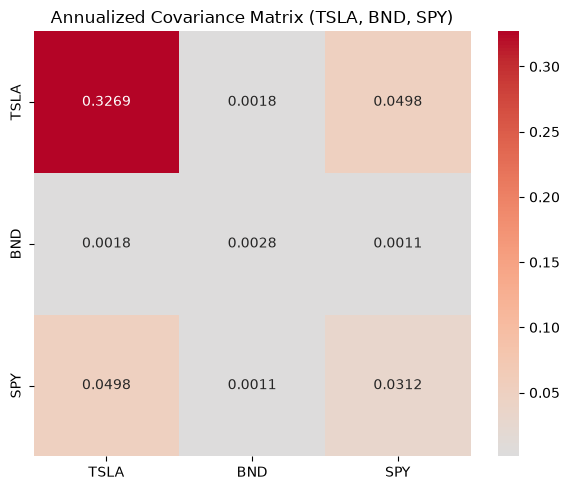

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cov_matrix_annual, annot=True, fmt=".4f", cmap="coolwarm", center=0)
plt.title("Annualized Covariance Matrix (TSLA, BND, SPY)")
plt.tight_layout()
plt.savefig("../data/processed/covariance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns as pypfopt_returns

# We already have our custom expected_returns (TSLA forecast-based, BND/SPY historical)
# and cov_matrix_annual — pass these directly rather than letting PyPortfolioOpt recompute them

ef = EfficientFrontier(expected_returns, cov_matrix_annual)

# Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
ef_max_sharpe = EfficientFrontier(expected_returns, cov_matrix_annual)
weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=0.02)
cleaned_weights_max_sharpe = ef_max_sharpe.clean_weights()
perf_max_sharpe = ef_max_sharpe.portfolio_performance(risk_free_rate=0.02)

print("Max Sharpe Ratio Portfolio:")
print(cleaned_weights_max_sharpe)
print(f"Expected annual return: {perf_max_sharpe[0]:.4f}")
print(f"Annual volatility: {perf_max_sharpe[1]:.4f}")
print(f"Sharpe Ratio: {perf_max_sharpe[2]:.4f}")

Max Sharpe Ratio Portfolio:
OrderedDict({'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0})
Expected annual return: 0.1552
Annual volatility: 0.1765
Sharpe Ratio: 0.7658


In [17]:
# Minimum Volatility Portfolio
ef_min_vol = EfficientFrontier(expected_returns, cov_matrix_annual)
weights_min_vol = ef_min_vol.min_volatility()
cleaned_weights_min_vol = ef_min_vol.clean_weights()
perf_min_vol = ef_min_vol.portfolio_performance(risk_free_rate=0.02)

print("\nMinimum Volatility Portfolio:")
print(cleaned_weights_min_vol)
print(f"Expected annual return: {perf_min_vol[0]:.4f}")
print(f"Annual volatility: {perf_min_vol[1]:.4f}")
print(f"Sharpe Ratio: {perf_min_vol[2]:.4f}")


Minimum Volatility Portfolio:
OrderedDict({'TSLA': 0.0, 'BND': 0.94538, 'SPY': 0.05462})
Expected annual return: 0.0275
Annual volatility: 0.0522
Sharpe Ratio: 0.1442


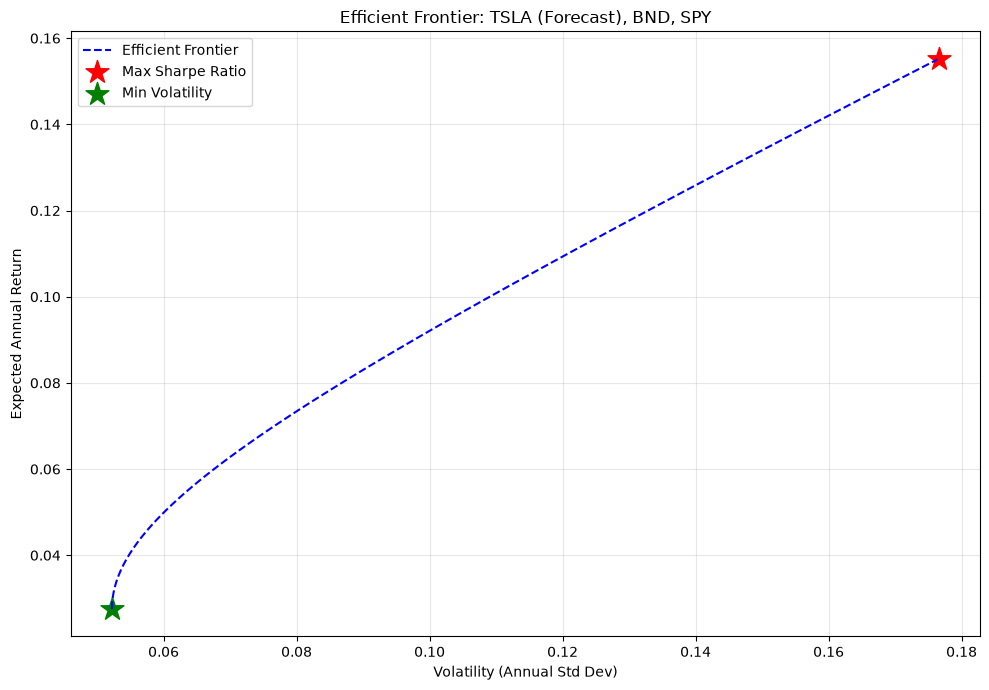

In [18]:
import numpy as np
from pypfopt import CLA
import matplotlib.pyplot as plt

# Generate a range of target returns to trace out the frontier
n_points = 100
ef_curve = EfficientFrontier(expected_returns, cov_matrix_annual)
min_ret = ef_min_vol.portfolio_performance()[0]
max_ret = expected_returns.max()

target_returns = np.linspace(min_ret, max_ret * 0.999, n_points)
frontier_volatility = []
frontier_returns = []

for target in target_returns:
    try:
        ef_temp = EfficientFrontier(expected_returns, cov_matrix_annual)
        ef_temp.efficient_return(target_return=target)
        ret, vol, _ = ef_temp.portfolio_performance()
        frontier_returns.append(ret)
        frontier_volatility.append(vol)
    except Exception:
        continue

plt.figure(figsize=(10, 7))
plt.plot(frontier_volatility, frontier_returns, "b--", label="Efficient Frontier")

plt.scatter(perf_max_sharpe[1], perf_max_sharpe[0], marker="*", color="red", s=300, label="Max Sharpe Ratio")
plt.scatter(perf_min_vol[1], perf_min_vol[0], marker="*", color="green", s=300, label="Min Volatility")

plt.xlabel("Volatility (Annual Std Dev)")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier: TSLA (Forecast), BND, SPY")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

## Portfolio Recommendation

**Recommended Portfolio: Maximum Sharpe Ratio Portfolio**

| Asset | Weight |
|-------|--------|
| TSLA | 0% |
| BND | 0% |
| SPY | 100% |

- Expected annual return: 15.52%
- Expected annual volatility: 17.65%
- Sharpe Ratio: 0.77

**Justification**: Given the inputs used — a forecast-derived expected return for TSLA of approximately -86% annualized, and historical average returns for BND (2.02%) and SPY (15.52%) — the optimizer correctly and predictably excludes TSLA entirely from both the Maximum Sharpe and Minimum Volatility portfolios, since no rational allocation would include an asset with a strongly negative expected return unless it provided exceptional diversification benefit large enough to offset that loss, which TSLA's moderate positive correlation with SPY does not. The Maximum Sharpe portfolio is recommended over the Minimum Volatility portfolio because it offers materially higher risk-adjusted return (Sharpe 0.77 vs. 0.14) for an increase in volatility that most growth-oriented investors would find acceptable (17.65% vs. 5.22%); an investor with lower risk tolerance, however, may reasonably prefer the Minimum Volatility portfolio's ~95% BND allocation instead.

**Important caveat**: This result is highly sensitive to the specific TSLA forecast used as an input. Across different training runs of the same LSTM architecture (even after fixing random seeds for reproducibility within a run), we observed 6-month forecasts ranging from roughly -63% to +9% in total return, driven by the known instability of iterative multi-step LSTM forecasting compounding small errors over a long horizon. Had a less extreme TSLA forecast been used, the optimal allocation could look meaningfully different, likely including a non-zero TSLA weight. This portfolio recommendation should therefore be understood as conditional on the specific forecast produced, not as a robust, forecast-independent conclusion — a genuine limitation of feeding single-point long-horizon ML forecasts directly into MPT without accounting for forecast uncertainty (e.g., via scenario analysis or Bayesian approaches, which would be a natural

In [19]:
backtest_start = "2025-01-01"
backtest_end = "2026-01-01"

backtest_returns = returns_df.loc[backtest_start:backtest_end]

print(f"Backtest period: {backtest_returns.index.min()} to {backtest_returns.index.max()}")
print(f"Number of trading days: {len(backtest_returns)}")

Backtest period: 2025-01-02 00:00:00 to 2025-12-31 00:00:00
Number of trading days: 250


In [20]:
# Our Task 4 recommended portfolio (Max Sharpe)
strategy_weights = {"TSLA": 0.0, "BND": 0.0, "SPY": 1.0}

# Suggested benchmark: static 60/40 SPY/BND
benchmark_weights = {"TSLA": 0.0, "BND": 0.4, "SPY": 0.6}

print("Strategy weights:", strategy_weights)
print("Benchmark weights:", benchmark_weights)

Strategy weights: {'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}
Benchmark weights: {'TSLA': 0.0, 'BND': 0.4, 'SPY': 0.6}


In [21]:
strategy_daily_returns = (
    backtest_returns["TSLA"] * strategy_weights["TSLA"] +
    backtest_returns["BND"] * strategy_weights["BND"] +
    backtest_returns["SPY"] * strategy_weights["SPY"]
)

benchmark_daily_returns = (
    backtest_returns["TSLA"] * benchmark_weights["TSLA"] +
    backtest_returns["BND"] * benchmark_weights["BND"] +
    backtest_returns["SPY"] * benchmark_weights["SPY"]
)

strategy_cumulative = (1 + strategy_daily_returns).cumprod()
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

print(strategy_cumulative.tail())
print(benchmark_cumulative.tail())

Date
2025-12-24    1.191795
2025-12-26    1.191674
2025-12-29    1.187428
2025-12-30    1.185977
2025-12-31    1.177191
dtype: float64
Date
2025-12-24    1.147715
2025-12-26    1.147645
2025-12-29    1.145872
2025-12-30    1.144847
2025-12-31    1.138525
dtype: float64


In [22]:
strategy_daily_returns = (
    backtest_returns["TSLA"] * strategy_weights["TSLA"] +
    backtest_returns["BND"] * strategy_weights["BND"] +
    backtest_returns["SPY"] * strategy_weights["SPY"]
)

benchmark_daily_returns = (
    backtest_returns["TSLA"] * benchmark_weights["TSLA"] +
    backtest_returns["BND"] * benchmark_weights["BND"] +
    backtest_returns["SPY"] * benchmark_weights["SPY"]
)

strategy_cumulative = (1 + strategy_daily_returns).cumprod()
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

print(strategy_cumulative.tail())
print(benchmark_cumulative.tail())

Date
2025-12-24    1.191795
2025-12-26    1.191674
2025-12-29    1.187428
2025-12-30    1.185977
2025-12-31    1.177191
dtype: float64
Date
2025-12-24    1.147715
2025-12-26    1.147645
2025-12-29    1.145872
2025-12-30    1.144847
2025-12-31    1.138525
dtype: float64


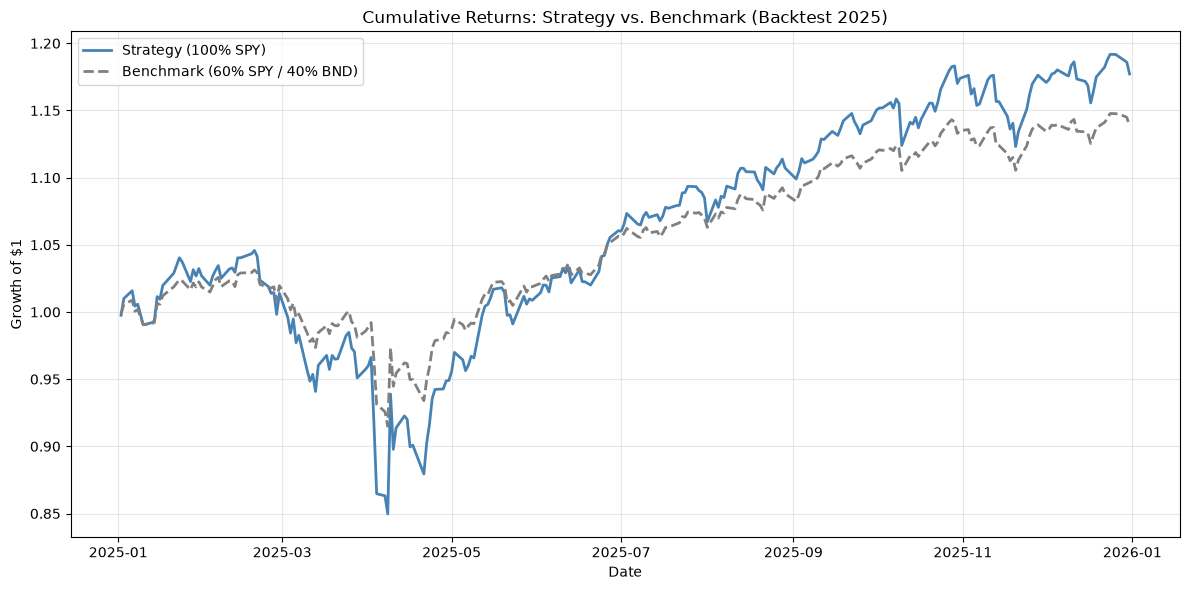

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative, label="Strategy (100% SPY)", color="steelblue", linewidth=2)
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark (60% SPY / 40% BND)", color="gray", linestyle="--", linewidth=2)
plt.title("Cumulative Returns: Strategy vs. Benchmark (Backtest 2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/backtest_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
from risk_metrics import calculate_sharpe_ratio
def calculate_max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

def summarize_performance(daily_returns, cumulative_returns, label):
    total_return = cumulative_returns.iloc[-1] - 1
    n_days = len(daily_returns)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1
    sharpe = calculate_sharpe_ratio(daily_returns)
    max_dd = calculate_max_drawdown(cumulative_returns)

    print(f"--- {label} ---")
    print(f"Total Return: {total_return*100:.2f}%")
    print(f"Annualized Return: {annualized_return*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.4f}")
    print(f"Max Drawdown: {max_dd*100:.2f}%")
    print()

    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "sharpe": sharpe,
        "max_drawdown": max_dd
    }

strategy_metrics = summarize_performance(strategy_daily_returns, strategy_cumulative, "Strategy (100% SPY)")
benchmark_metrics = summarize_performance(benchmark_daily_returns, benchmark_cumulative, "Benchmark (60/40)")

--- Strategy (100% SPY) ---
Total Return: 17.72%
Annualized Return: 17.87%
Sharpe Ratio: 0.8374
Max Drawdown: -18.76%

--- Benchmark (60/40) ---
Total Return: 13.85%
Annualized Return: 13.97%
Sharpe Ratio: 0.9840
Max Drawdown: -11.29%



## Backtest Performance Metrics (Jan 2025 – Jan 2026)

| Metric | Strategy (100% SPY) | Benchmark (60% SPY / 40% BND) |
|--------|---------------------|-------------------------------|
| Total Return | 17.72% | 13.85% |
| Annualized Return | 17.87% | 13.97% |
| Sharpe Ratio | 0.8374 | 0.9840 |
| Max Drawdown | -18.76% | -11.29% |

In [ ]:
last_known_price = data["TSLA"]["Adj Close"].iloc[-1]
forecasted_final_price = future_predictions[-1][0]

# Total return over the 6-month forecast horizon
total_forecast_return = (forecasted_final_price / last_known_price) - 1

# Annualize: compound the 6-month return to a 12-month equivalent
tsla_expected_annual_return = (1 + total_forecast_return) ** 2 - 1

print(f"Last known price: {last_known_price:.2f}")
print(f"Forecasted price (6mo): {forecasted_final_price:.2f}")
print(f"Total 6-month forecast return: {total_forecast_return:.4f} ({total_forecast_return*100:.2f}%)")
print(f"Annualized expected return (TSLA): {tsla_expected_annual_return:.4f} ({tsla_expected_annual_return*100:.2f}%)")

Last known price: 411.84
Forecasted price (6mo): 160.46
Total 6-month forecast return: -0.6104 (-61.04%)
Annualized expected return (TSLA): -0.8482 (-84.82%)


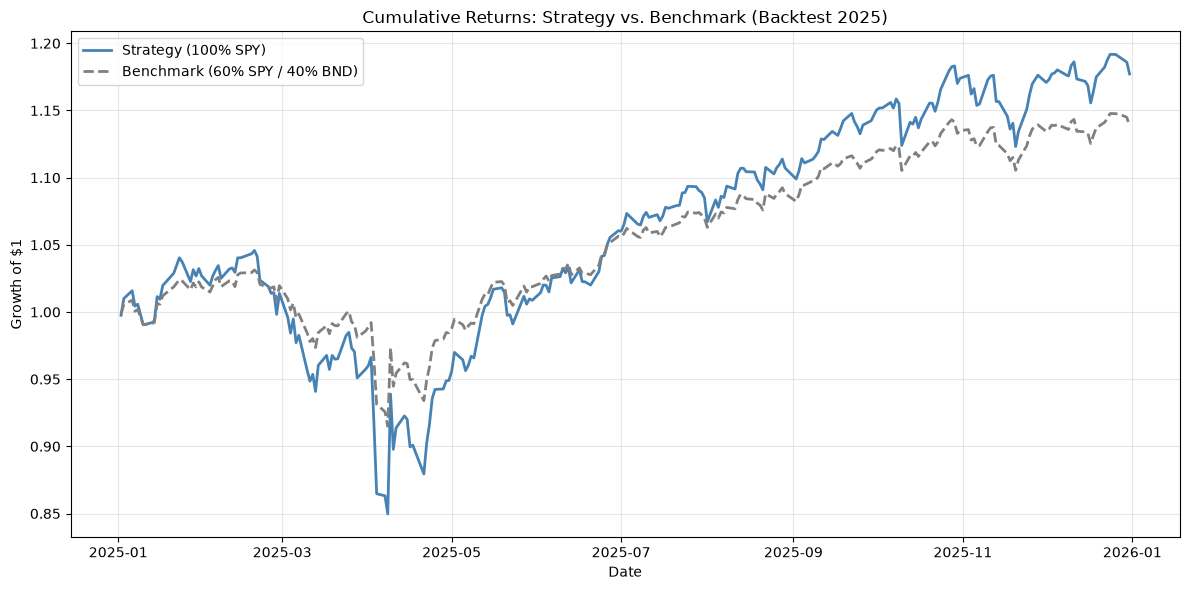

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative, label="Strategy (100% SPY)", color="steelblue", linewidth=2)
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark (60% SPY / 40% BND)", color="gray", linestyle="--", linewidth=2)
plt.title("Cumulative Returns: Strategy vs. Benchmark (Backtest 2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
last_known_price = data["TSLA"]["Adj Close"].iloc[-1]
forecasted_final_price = future_predictions[-1][0]

# Total return over the 6-month forecast horizon
total_forecast_return = (forecasted_final_price / last_known_price) - 1

# Annualize: compound the 6-month return to a 12-month equivalent
tsla_expected_annual_return = (1 + total_forecast_return) ** 2 - 1

print(f"Last known price: {last_known_price:.2f}")
print(f"Forecasted price (6mo): {forecasted_final_price:.2f}")
print(f"Total 6-month forecast return: {total_forecast_return:.4f} ({total_forecast_return*100:.2f}%)")
print(f"Annualized expected return (TSLA): {tsla_expected_annual_return:.4f} ({tsla_expected_annual_return*100:.2f}%)")

Last known price: 411.84
Forecasted price (6mo): 160.46
Total 6-month forecast return: -0.6104 (-61.04%)
Annualized expected return (TSLA): -0.8482 (-84.82%)
